In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [16]:
# Load the dataset
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
                'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
                'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
                'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
                'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
                'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
                'dst_host_srv_rerror_rate', 'label']

df = pd.read_csv('kddcup.data', header=None, names=column_names)

In [17]:
df.shape

(4898431, 42)

In [18]:
df.head(3)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,normal.


In [19]:
'''# Step 1: Load Dataset
from sklearn.datasets import fetch_kddcup99
data = fetch_kddcup99(subset="SA", percent10=True)
df = pd.DataFrame(data.data)
df.columns = data.feature_names
df['target'] = data.target'''

'# Step 1: Load Dataset\nfrom sklearn.datasets import fetch_kddcup99\ndata = fetch_kddcup99(subset="SA", percent10=True)\ndf = pd.DataFrame(data.data)\ndf.columns = data.feature_names\ndf[\'target\'] = data.target'

In [20]:
# Step 2: Encode Categorical Features
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [21]:
# Step 3: Split Dataset
X = df.drop('label', axis=1)
y = df['label']
y = LabelEncoder().fit_transform(y)
y_cat = to_categorical(y)

# Train, validation, test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp.argmax(axis=1))

In [22]:
# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Step 4: LSTM Model for Feature Extraction
model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_lstm, y_train, epochs=5, batch_size=128, validation_data=(X_val_lstm, y_val), verbose=1)

# Extract LSTM features
feature_extractor = Sequential(model.layers[:-1])  # remove last classification layer
X_train_feat = feature_extractor.predict(X_train_lstm)
X_val_feat = feature_extractor.predict(X_val_lstm)
X_test_feat = feature_extractor.predict(X_test_lstm)

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
22962/22962 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.9949 - loss: 0.0528 - val_accuracy: 0.9996 - val_loss: 0.0014
Epoch 2/5
22962/22962 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 3/5
22962/22962 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 4/5
22962/22962 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 5/5
22962/22962 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9997 - loss: 9.0293e-04 - val_accuracy: 0.9998 - val_loss: 9.4218e-04
91846/91846 ━━━━━━━━━━━━━━━━━━━━ 54s 587us/step
30616/30616 ━━━━━━━━━━━━━━━━━━━━ 25s 802us/step
30616/30616 ━━━━━━━━━━━━━━━━━━━━ 26s 854us/step


In [23]:
# Step 5: Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_feat, y_train.argmax(axis=1))
y_pred = clf.predict(X_test_feat)

# Evaluation
y_true = y_test.argmax(axis=1)
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       441
           1       1.00      0.67      0.80         6
           2       0.00      0.00      0.00         2
           3       1.00      0.91      0.95        11
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00      2496
           6       0.50      0.75      0.60         4
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00    214403
          10       0.99      0.98      0.98       463
          11       1.00      1.00      1.00    194556
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       0.98      0.96      0.97        53
          15       1.00      1.00      1.00      2083
          16       0.00      0.00      0.00         2
  

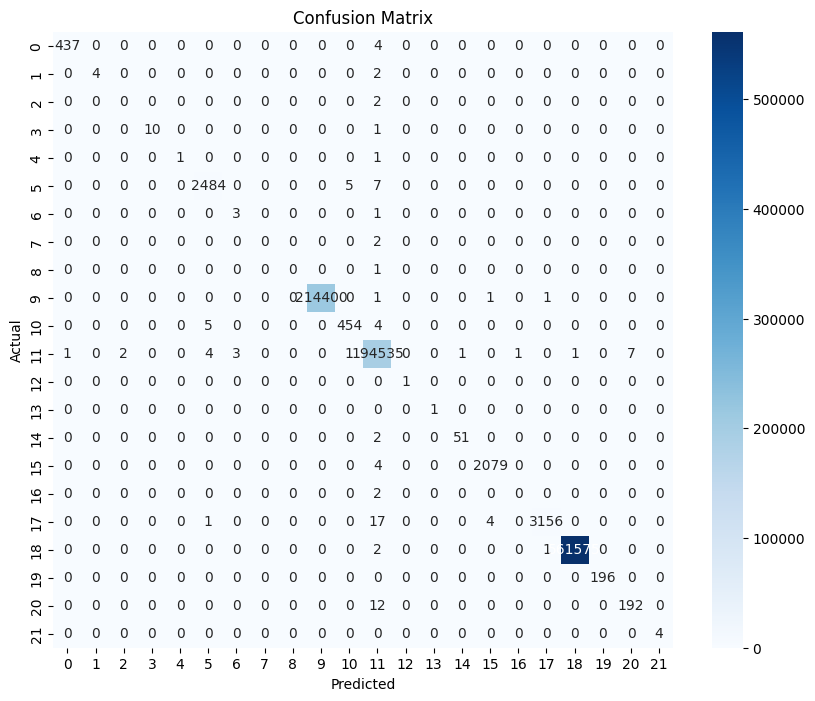

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


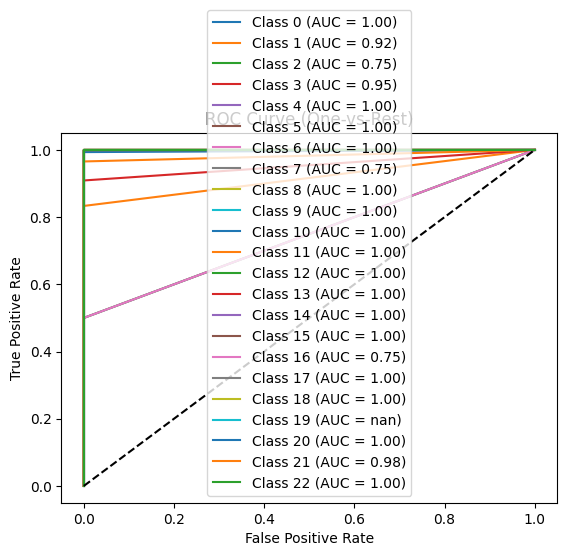

In [25]:
# Precision-Recall & ROC Curve (One-vs-Rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

n_classes = y_train.shape[1]
y_score = clf.predict_proba(X_test_feat)
y_test_bin = y_test

# ROC Curve
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


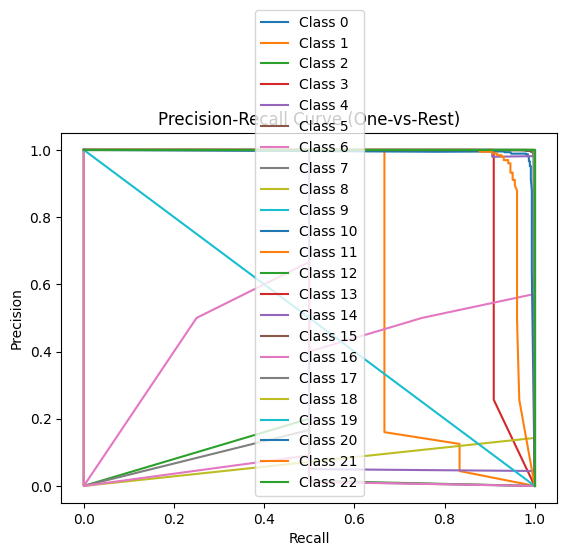

In [26]:
# Precision-Recall Curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])

plt.figure()
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label='Class {}'.format(i))
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (One-vs-Rest)")
plt.legend()
plt.show()
